# M5: Baseline, Model Development and Evaluation
**Role:** Member 5 (M5) · **Rubric items:** Predictive model development (4 marks) · Model evaluation and result interpretation (3 marks)

Continues from M4 using `m4_train.csv`, `m4_test.csv` and `m4_feature_list.csv` as saved (no change to the data).

| Item | Detail |
|---|---|
| **Prediction task** | Binary classification: `high_risk` = 1 when AQI > 300 |
| **Lead time** | Next-day warning (pollution inputs only up to day t-1) |
| **Data split** | M4 temporal split: train 2018–2024 (78%), test Jan 2025 – Sep 2026 (22%) |
| **Priority metric** | Recall (a missed high-risk day costs most), with false alarms tracked |

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

# ---- Paths ----
DATA = Path(".")                      # folder with M4 outputs
FIG  = Path("M5_figures"); FIG.mkdir(exist_ok=True)
SEED = 42

# ---- Chart style (same as M3 / M4) ----
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlecolor": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9.5, "figure.dpi": 110,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 2. Load M4 outputs

In [2]:
train = pd.read_csv(DATA / "m4_train.csv", parse_dates=["date"])
test  = pd.read_csv(DATA / "m4_test.csv",  parse_dates=["date"])
M4_FEATURES = pd.read_csv(DATA / "m4_feature_list.csv")["feature"].tolist()
TARGET = "high_risk"

y_train, y_test = train[TARGET].astype(int), test[TARGET].astype(int)
print(f"M4 features: {len(M4_FEATURES)}")
for name, d, y in [("Train", train, y_train), ("Test", test, y_test)]:
    print(f"{name:5s}: {d.date.min().date()} -> {d.date.max().date()} | {len(d)} rows | high_risk = {y.mean():.1%}")

M4 features: 99
Train: 2018-01-04 -> 2024-12-31 | 2285 rows | high_risk = 28.9%
Test : 2025-01-01 -> 2026-09-29 | 635 rows | high_risk = 20.2%


## 3. Leakage check on model inputs
Four M4 features carry **same-day** pollution values, which are not known when a next-day warning is issued.
They rebuild today's PM2.5 (and so the target), so they are excluded from the model inputs only. Same-day weather is kept: in use it comes from the next-day weather forecast.

In [3]:
rebuilt = train["pm25_mean_lag1"] + train["pm25_mean_change"]
ok = rebuilt.notna() & train["pm25_mean"].notna()
print(f"pm25_mean_lag1 + pm25_mean_change == today's pm25_mean : {np.isclose(rebuilt[ok], train.pm25_mean[ok]).mean():.0%} of rows")

rebuilt = train["pm25_pm10_ratio"] * train["pm10_mean"]
ok = rebuilt.notna() & train["pm25_mean"].notna()
print(f"pm25_pm10_ratio x pm10_mean == today's pm25_mean       : {np.isclose(rebuilt[ok], train.pm25_mean[ok]).mean():.0%} of rows")

SAME_DAY_POLLUTION = ["pm25_mean_change", "pm10_mean", "pm25_pm10_ratio", "pm10_available"]
FEATURES = [f for f in M4_FEATURES if f not in SAME_DAY_POLLUTION]
print(f"\nModel inputs: {len(FEATURES)} features ({len(SAME_DAY_POLLUTION)} same-day pollution columns excluded)")

X_train, X_test = train[FEATURES], test[FEATURES]

pm25_mean_lag1 + pm25_mean_change == today's pm25_mean : 100% of rows
pm25_pm10_ratio x pm10_mean == today's pm25_mean       : 100% of rows

Model inputs: 95 features (4 same-day pollution columns excluded)


## 4. Baseline: persistence ("tomorrow = today")
Predicts today's class as yesterday's. Any model must beat this to be useful.
An **episode start** is a high-risk day that follows a normal day; persistence can never warn about these.

In [4]:
episode_start = ((test[TARGET] == 1) & (test["prev_high_risk"] == 0)).values
print(f"Episode starts in test set: {episode_start.sum()}")

def evaluate(name, y_true, y_pred, y_prob=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        "False alarms": fp,
        "Missed days":  fn,
        "Episode starts caught": f"{int(y_pred[episode_start].sum())}/{episode_start.sum()}",
    }

pred_base = test["prev_high_risk"].fillna(0).astype(int).values   # 1 test day has no previous value
results = [evaluate("Persistence baseline", y_test, pred_base)]
pd.DataFrame(results).set_index("Model").round(3)

Episode starts in test set: 16


,Accuracy,Precision,Recall,F1,ROC-AUC,False alarms,Missed days,Episode starts caught
Model,,,,,,,,
Persistence baseline,0.946,0.867,0.867,0.867,NaN,17,17,0/16


## 5. Model development

| Model | Reason for choice |
|---|---|
| **Logistic Regression** | Linear, interpretable reference model |
| **Random Forest** | Captures non-linear weather × pollution interactions; robust to outliers |
| **Histogram Gradient Boosting** | Strong on tabular data; handles missing PM10 lags natively |

**Settings:** `class_weight="balanced"` for the 29% positive class · median imputation fitted inside the pipeline (train only) · hyper-parameters tuned by grid search with 5-fold `TimeSeriesSplit` on the training years (scoring = F1), so validation folds are always later than training folds.

In [5]:
models = {
    "Logistic Regression": (
        make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      LogisticRegression(max_iter=5000, class_weight="balanced")),
        {"logisticregression__C": [0.01, 0.1, 1, 10]}),
    "Random Forest": (
        make_pipeline(SimpleImputer(strategy="median"),
                      RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)),
        {"randomforestclassifier__max_depth": [4, 8, None],
         "randomforestclassifier__min_samples_leaf": [1, 5, 10]}),
    "Gradient Boosting": (
        HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
        {"learning_rate": [0.03, 0.1], "max_depth": [3, None], "max_iter": [100, 300]}),
}

cv = TimeSeriesSplit(n_splits=5)
fitted, tuning = {}, []
for name, (model, grid) in models.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring="f1", n_jobs=-1).fit(X_train, y_train)
    fitted[name] = gs.best_estimator_
    i = gs.best_index_
    tuning.append({"Model": name,
                   "Best parameters": {k.split("__")[-1]: v for k, v in gs.best_params_.items()},
                   "CV F1 (mean)": round(gs.cv_results_["mean_test_score"][i], 3),
                   "CV F1 (std)":  round(gs.cv_results_["std_test_score"][i], 3)})

tuning = pd.DataFrame(tuning).set_index("Model")
tuning

,Best parameters,CV F1 (mean),CV F1 (std)
Model,,,
Logistic Regression,{'C': 0.1},0.861,0.046
Random Forest,"{'max_depth': 8, 'min_samples_leaf': 1}",0.865,0.048
Gradient Boosting,"{'learning_rate': 0.03, 'max_depth': None, 'ma...",0.870,0.041


## 6. Evaluation on the test set (Jan 2025 – Sep 2026)

In [6]:
probs, preds = {}, {"Persistence baseline": pred_base}
for name, model in fitted.items():
    probs[name] = model.predict_proba(X_test)[:, 1]
    preds[name] = model.predict(X_test)
    results.append(evaluate(name, y_test, preds[name], probs[name]))

metrics = pd.DataFrame(results).set_index("Model")
metrics.style.format({c: "{:.3f}" for c in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]}, na_rep="–") \
       .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], color="#cde2fb")

,Accuracy,Precision,Recall,F1,ROC-AUC,False alarms,Missed days,Episode starts caught
Model,,,,,,,,
Persistence baseline,0.946,0.867,0.867,0.867,–,17,17,0/16
Logistic Regression,0.940,0.804,0.930,0.862,0.985,29,9,8/16
Random Forest,0.934,0.779,0.938,0.851,0.984,34,8,11/16
Gradient Boosting,0.948,0.837,0.922,0.877,0.982,23,10,9/16


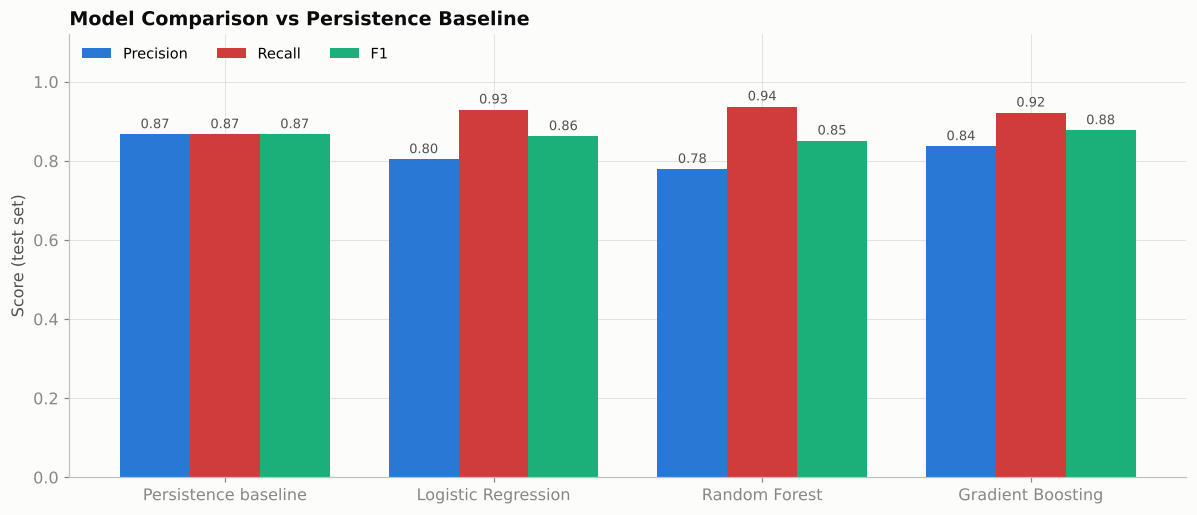

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
cols, colors = ["Precision", "Recall", "F1"], [BLUE, RED, AQUA]
x, w = np.arange(len(metrics)), 0.26
for j, (c, col) in enumerate(zip(cols, colors)):
    bars = ax.bar(x + (j - 1) * w, metrics[c], w, color=col, label=c)
    ax.bar_label(bars, fmt="%.2f", fontsize=8.5, color=INK2, padding=2)
ax.set_xticks(x); ax.set_xticklabels(metrics.index)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score (test set)")
ax.set_title("Model Comparison vs Persistence Baseline"); ax.legend(loc="upper left", ncol=3)
fig.tight_layout(); save(fig, "01_model_comparison")

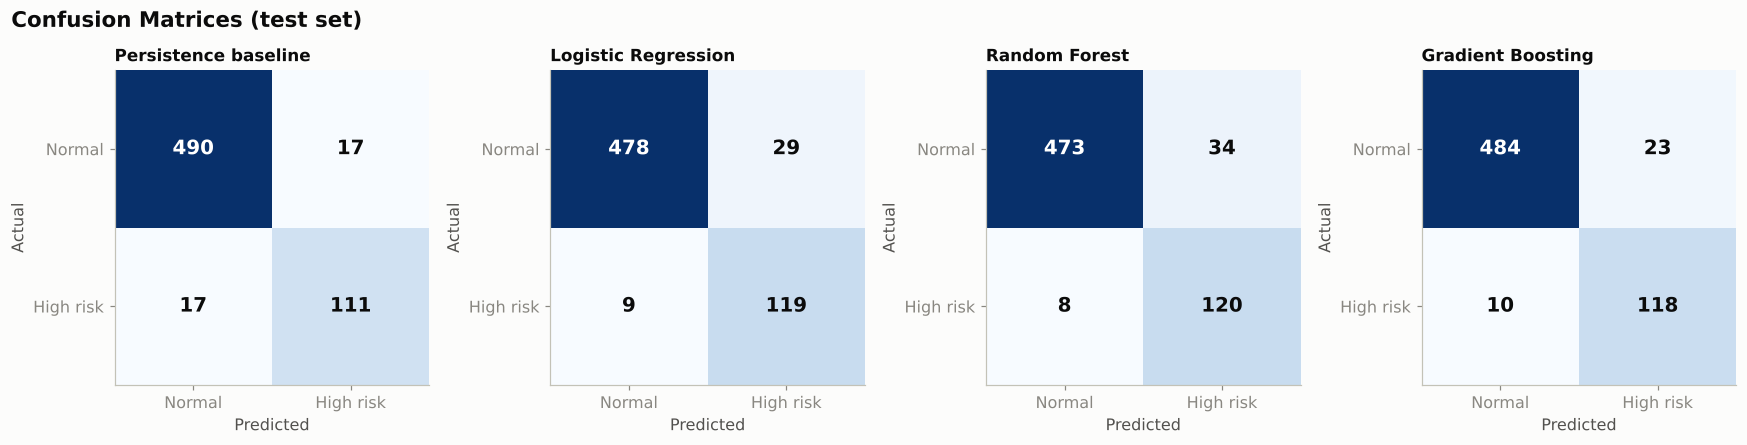

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, p)
    ax.imshow(cm, cmap="Blues"); ax.grid(False)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, v, ha="center", va="center", fontsize=13, fontweight="bold",
                color="white" if v > cm.max() / 2 else INK)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "High risk"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "High risk"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(name, fontsize=11)
fig.suptitle("Confusion Matrices (test set)", x=0.01, ha="left", fontsize=14, fontweight="bold", color=INK)
fig.tight_layout(); save(fig, "02_confusion_matrices")

## 7. Final model
Selected on **cross-validated F1 from the training years**, not on the test set.

In [9]:
BEST = tuning["CV F1 (mean)"].idxmax()
final = fitted[BEST]
print(f"Selected model: {BEST}\n")
print(classification_report(y_test, preds[BEST], target_names=["Normal", "High risk"], digits=3))

Selected model: Gradient Boosting

              precision    recall  f1-score   support

      Normal      0.980     0.955     0.967       507
   High risk      0.837     0.922     0.877       128

    accuracy                          0.948       635
   macro avg      0.908     0.938     0.922       635
weighted avg      0.951     0.948     0.949       635



## 8. Interpretation: which inputs drive the prediction

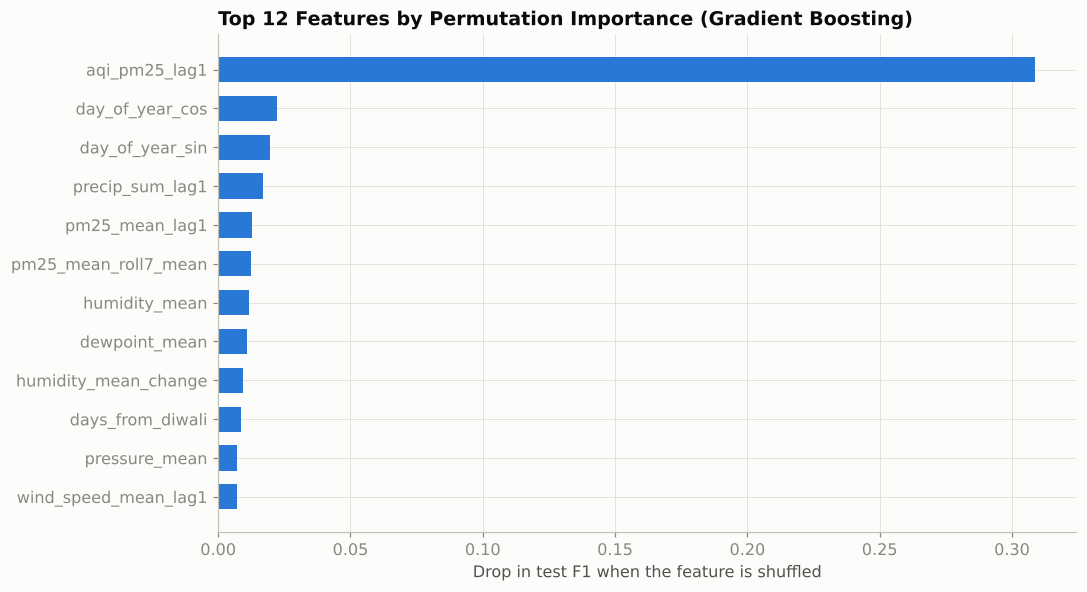

In [10]:
imp = permutation_importance(final, X_test, y_test, scoring="f1", n_repeats=10, random_state=SEED, n_jobs=-1)
imp = pd.Series(imp.importances_mean, index=FEATURES).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(imp.index[::-1], imp.values[::-1], color=BLUE, height=0.65)
ax.set_xlabel("Drop in test F1 when the feature is shuffled")
ax.set_title(f"Top 12 Features by Permutation Importance ({BEST})")
fig.tight_layout(); save(fig, "03_feature_importance")

## 9. Early-warning view: winter 2025–26

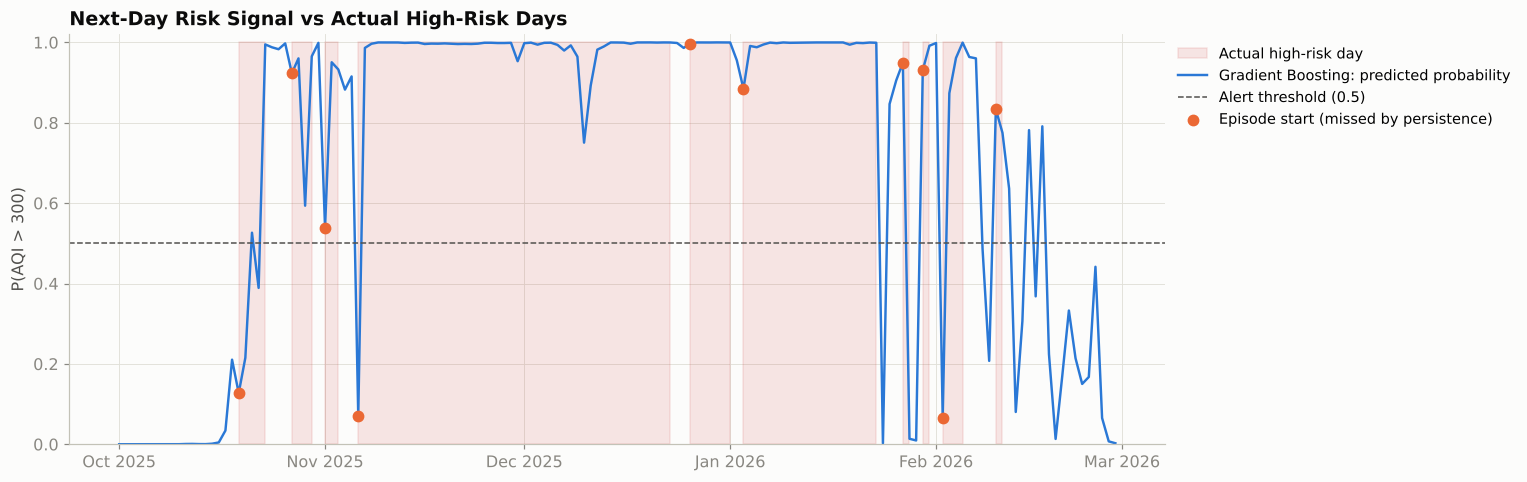

In [11]:
win = (test.date >= "2025-10-01") & (test.date <= "2026-02-28")
d, p = test.loc[win, "date"], probs[BEST][win.values]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(d, 0, 1, where=y_test[win].values == 1, color=RED, alpha=0.12, step="mid", label="Actual high-risk day")
ax.plot(d, p, color=BLUE, lw=1.6, label=f"{BEST}: predicted probability")
ax.axhline(0.5, color=INK2, lw=1, ls="--", label="Alert threshold (0.5)")
s = episode_start[win.values]
ax.scatter(d[s], p[s], color=ORANGE, s=45, zorder=3, label="Episode start (missed by persistence)")
ax.set_ylim(0, 1.02); ax.set_ylabel("P(AQI > 300)")
ax.set_title("Next-Day Risk Signal vs Actual High-Risk Days")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout(); save(fig, "04_early_warning_winter")

## 10. Results and business findings

**Results**
- **Gradient Boosting** (selected on CV F1) has the best test F1 (0.877) and accuracy (0.948).
- Against persistence, recall rises from 0.867 to 0.922 (missed days 17 → 10) for 6 extra false alarms (17 → 23).
- All three models warn on 8–11 of the 16 episode starts; persistence warns on none.

**Interpretation**
- *Strengths:* temporal split and time-ordered CV with no same-day pollution inputs, so no leakage; ROC-AUC ≈ 0.98; high recall, which is the business priority.
- *Limitations:* the F1 gain over persistence is small (0.877 vs 0.867) because yesterday's AQI dominates (importance 0.31 vs ≤ 0.03 for any other input). Same-day weather assumes an accurate next-day forecast. Lead time is 1 day only. The PM2.5-only AQI approximates the official AQI. The test period has fewer high-risk days than training (20% vs 29%).

**Initial business findings**
- Yesterday's AQI is the strongest signal: after a very poor day, plan for the next day to be high risk too.
- Season (day of year), previous-day rainfall, humidity, pressure and Diwali proximity add the signal that lets the model warn at the **start** of an episode, which a "tomorrow = today" rule cannot.
- Late October to early February is the main risk window; in winter 2025–26 the model's alerts closely track actual episodes (Section 9).
- Use as a next-day alert for construction, logistics, schools and events. Where a missed day costs more than a false alarm, Random Forest is the higher-recall option (recall 0.938, 11/16 episode starts).

## 11. Save outputs

In [12]:
metrics.to_csv("m5_model_metrics.csv")
out = test[["date", TARGET]].copy()
out["pred_baseline"] = pred_base
for name in fitted:
    key = name.lower().replace(" ", "_")
    out[f"prob_{key}"] = probs[name].round(4)
    out[f"pred_{key}"] = preds[name]
out.to_csv("m5_test_predictions.csv", index=False)
print("Saved: m5_model_metrics.csv, m5_test_predictions.csv, figures in M5_figures/")

Saved: m5_model_metrics.csv, m5_test_predictions.csv, figures in M5_figures/
